In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, linewidth=160)
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

In [ ]:
max_inventory = 8
max_order = 5

states = list(range(max_inventory + 1))
actions = list(range(max_order + 1))

# Demand distribution: P(D = d)
# Chosen to be small, non-uniform
demand_probs = {
    0: 0.10,
    1: 0.20,
    2: 0.30,
    3: 0.25,
    4: 0.10,
    5: 0.05,
}

assert abs(sum(demand_probs.values()) - 1.0) < 1e-9

# Reward design
sale_price = 8.0
unit_order_cost = 3.0
holding_cost = 1.0
stockout_penalty = 2.0

gamma = 0.95

print("States:", states)
print("Actions:", actions)
print("Demand distribution:", demand_probs)
print("gamma =", gamma)

States: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Actions: [0, 1, 2, 3, 4, 5]
Demand distribution: {0: 0.1, 1: 0.2, 2: 0.3, 3: 0.25, 4: 0.1, 5: 0.05}
gamma = 0.95


In [4]:
# Cell 3: Transition and reward function

def step(state, action, demand):
    """
    Given current state (inventory), action (order amount), and realized demand,
    return: next_state, reward
    """
    # Apply order (cannot exceed max capacity)
    inventory = min(state + action, max_inventory)
    
    # Sales happen
    sales = min(inventory, demand)
    
    # Unsatisfied demand (lost sales)
    unmet_demand = max(demand - inventory, 0)
    
    # Remaining inventory after sales
    next_inventory = inventory - sales
    
    # Reward calculation
    revenue = sales * sale_price
    ordering_cost = action * unit_order_cost
    holding = next_inventory * holding_cost
    stockout = unmet_demand * stockout_penalty
    
    reward = revenue - ordering_cost - holding - stockout
    
    return next_inventory, reward


for s in [0, 3, 6]:
    for a in [0, 2]:
        for d in [0, 3]:
            ns, r = step(s, a, d)
            print(f"s={s}, a={a}, d={d} -> s'={ns}, r={round(r,2)}")

s=0, a=0, d=0 -> s'=0, r=0.0
s=0, a=0, d=3 -> s'=0, r=-6.0
s=0, a=2, d=0 -> s'=2, r=-8.0
s=0, a=2, d=3 -> s'=0, r=8.0
s=3, a=0, d=0 -> s'=3, r=-3.0
s=3, a=0, d=3 -> s'=0, r=24.0
s=3, a=2, d=0 -> s'=5, r=-11.0
s=3, a=2, d=3 -> s'=2, r=16.0
s=6, a=0, d=0 -> s'=6, r=-6.0
s=6, a=0, d=3 -> s'=3, r=21.0
s=6, a=2, d=0 -> s'=8, r=-14.0
s=6, a=2, d=3 -> s'=5, r=13.0


In [5]:
def expected_return(state, action, V, gamma):
    total = 0.0
    for demand, prob in demand_probs.items():
        next_state, reward = step(state, action, demand)
        total += prob * (reward + gamma * V[next_state])
    return total


def value_iteration(states, actions, gamma, tol=1e-8, max_iters=1000):
    V = np.zeros(len(states))
    
    for it in range(max_iters):
        delta = 0.0
        V_new = np.copy(V)
        
        for s in states:
            action_values = [expected_return(s, a, V, gamma) for a in actions]
            V_new[s] = max(action_values)
            delta = max(delta, abs(V_new[s] - V[s]))
        
        V = V_new
        
        if delta < tol:
            print(f"Value iteration converged in {it + 1} iterations.")
            break
    else:
        print("Warning: value iteration hit max_iters without full convergence.")
    
    # Extract greedy policy
    policy = np.zeros(len(states), dtype=int)
    q_table = np.zeros((len(states), len(actions)))
    
    for s in states:
        for a in actions:
            q_table[s, a] = expected_return(s, a, V, gamma)
        policy[s] = int(np.argmax(q_table[s]))
    
    return V, policy, q_table


V, policy, q_table = value_iteration(states, actions, gamma)

print("\nOptimal value function:")
for s in states:
    print(f"State {s}: V({s}) = {V[s]:.4f}")

print("\nOptimal policy (order quantity by inventory level):")
for s in states:
    print(f"Inventory {s} -> order {policy[s]}")

Value iteration converged in 403 iterations.

Optimal value function:
State 0: V(0) = 170.4500
State 1: V(1) = 173.4500
State 2: V(2) = 176.4500
State 3: V(3) = 179.4500
State 4: V(4) = 182.4500
State 5: V(5) = 184.6296
State 6: V(6) = 186.1866
State 7: V(7) = 187.3546
State 8: V(8) = 188.0295

Optimal policy (order quantity by inventory level):
Inventory 0 -> order 4
Inventory 1 -> order 3
Inventory 2 -> order 2
Inventory 3 -> order 1
Inventory 4 -> order 0
Inventory 5 -> order 0
Inventory 6 -> order 0
Inventory 7 -> order 0
Inventory 8 -> order 0


 State (starting inventory)  Optimal Value V(s)  Optimal Action (order units)
                          0            170.4500                             4
                          1            173.4500                             3
                          2            176.4500                             2
                          3            179.4500                             1
                          4            182.4500                             0
                          5            184.6296                             0
                          6            186.1866                             0
                          7            187.3546                             0
                          8            188.0295                             0


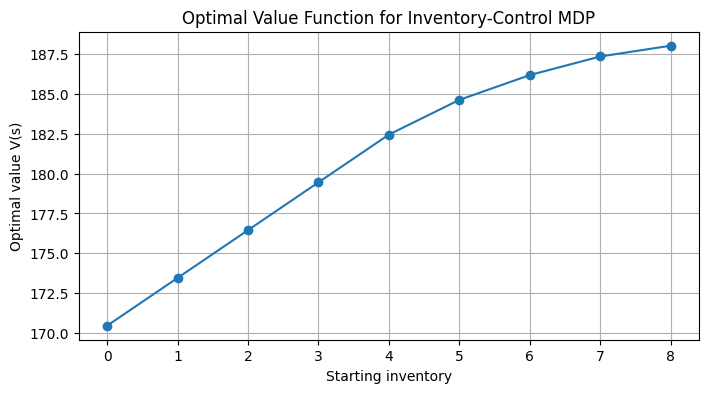

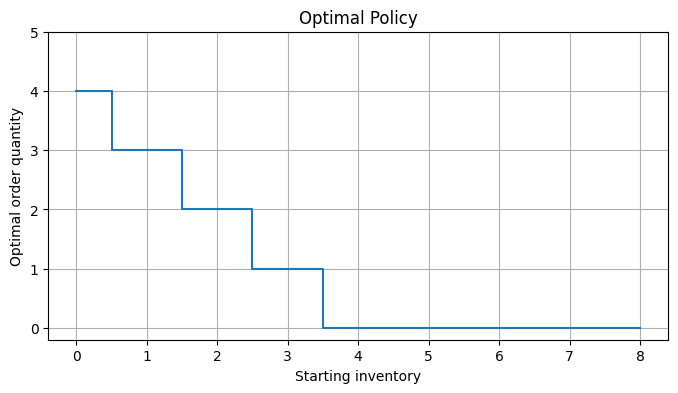

In [6]:
import pandas as pd

results_df = pd.DataFrame({
    "State (starting inventory)": states,
    "Optimal Value V(s)": np.round(V, 4),
    "Optimal Action (order units)": policy
})

print(results_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(states, V, marker='o')
plt.xlabel("Starting inventory")
plt.ylabel("Optimal value V(s)")
plt.title("Optimal Value Function for Inventory-Control MDP")
plt.show()

plt.figure(figsize=(8, 4))
plt.step(states, policy, where='mid')
plt.xlabel("Starting inventory")
plt.ylabel("Optimal order quantity")
plt.title("Optimal Policy")
plt.yticks(actions)
plt.show()

Value iteration converged in 403 iterations.
Value iteration converged in 403 iterations.
Value iteration converged in 402 iterations.
Value iteration converged in 402 iterations.
 State  penalty=0.5  penalty=2.0  penalty=5.0  penalty=10.0
     0            3            4            4             4
     1            2            3            3             3
     2            1            2            2             2
     3            0            1            1             1
     4            0            0            0             0
     5            0            0            0             0
     6            0            0            0             0
     7            0            0            0             0
     8            0            0            0             0


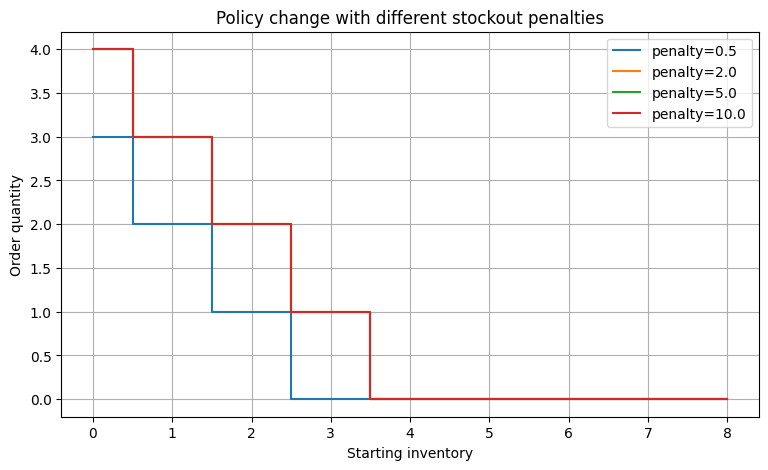

In [7]:
def run_with_stockout_penalty(new_penalty):
    global stockout_penalty
    
    old_penalty = stockout_penalty
    stockout_penalty = new_penalty
    
    V_exp, policy_exp, _ = value_iteration(states, actions, gamma)
    
    stockout_penalty = old_penalty  # restore
    
    return policy_exp


penalties = [0.5, 2.0, 5.0, 10.0]
policies = {}

for p in penalties:
    policies[p] = run_with_stockout_penalty(p)

# Display policies side-by-side
import pandas as pd

df_exp = pd.DataFrame({
    "State": states,
    **{f"penalty={p}": policies[p] for p in penalties}
})

print(df_exp.to_string(index=False))

# Plot comparison
plt.figure(figsize=(9, 5))

for p in penalties:
    plt.step(states, policies[p], where='mid', label=f"penalty={p}")

plt.xlabel("Starting inventory")
plt.ylabel("Order quantity")
plt.title("Policy change with different stockout penalties")
plt.legend()
plt.show()

# Part 1: Inventory-Control MDP

## Setup
- **State:** inventory level $(s \in \{0,\dots,8\})$
- **Action:** order quantity $(a \in \{0,\dots,5\})$
- **Dynamics:** inventory updates after ordering and random demand
- **Reward:**  
  revenue − ordering cost − holding cost − stockout penalty
- **Discount:** $(\gamma = 0.95)$

## Why MDP
The next state and reward depend only on current inventory, action, and demand -> satisfies the Markov property.

## Method
Used **value iteration** to compute:
$
V(s) = \max_a \mathbb{E}[r + \gamma V(s')]
$

## Results
Optimal policy:
- Order up to ~4 units:
  - 0->4, 1->3, 2->2, 3->1, >=4->0  
-> a **base-stock policy**

## Experiment (Stockout Penalty)
- Low penalty (0.5) -> target inventory ≈ 3  
- Higher penalties (2–10) -> target ≈ 4  

## Insight
Higher stockout penalties -> more conservative policy (hold more inventory).  
The agent balances ordering, holding, and lost-demand costs.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12)

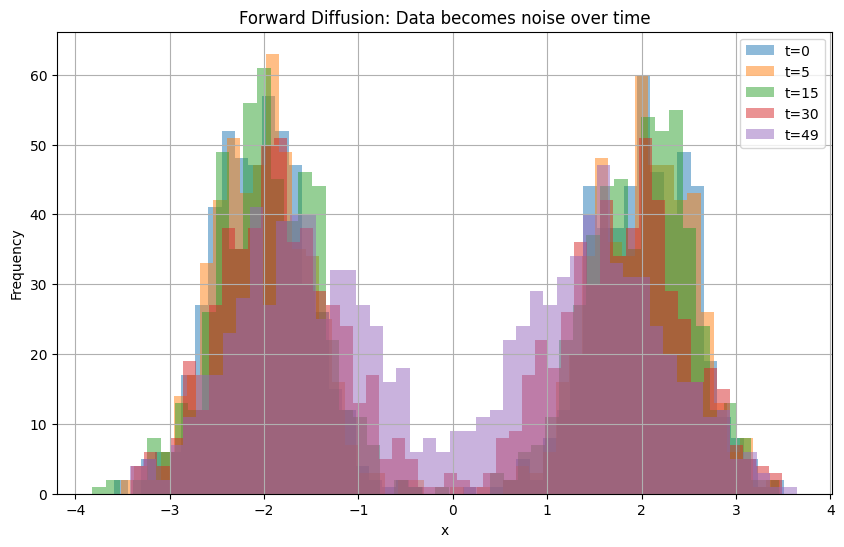

In [11]:
# Create a simple 1D dataset (mixture of Gaussians)
n_samples = 1000
data = np.concatenate([
    np.random.normal(-2, 0.5, n_samples // 2),
    np.random.normal(2, 0.5, n_samples // 2)
])

# Diffusion parameters
T = 50  # number of diffusion steps
betas = np.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

# Forward diffusion: x_t = sqrt(alpha_bar)*x_0 + sqrt(1-alpha_bar)*noise
def forward_diffusion(x0, t):
    noise = np.random.randn(*x0.shape)
    return np.sqrt(alpha_bars[t]) * x0 + np.sqrt(1 - alpha_bars[t]) * noise

# Visualize at different timesteps
timesteps = [0, 5, 15, 30, 49]

plt.figure(figsize=(10, 6))

for i, t in enumerate(timesteps):
    xt = forward_diffusion(data, t)
    plt.hist(xt, bins=50, alpha=0.5, label=f"t={t}")

plt.title("Forward Diffusion: Data becomes noise over time")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Part 2: Diffusion Models

## Goal
Diffusion models generate data by gradually converting noise into structured samples.  
This experiment visualizes the **forward diffusion process**.

## Forward Process
At each step:
$
x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon
$

- \($x_0$\): original data  
- \($\epsilon \sim \mathcal{N}(0,1)$\): noise  
- \($\bar{\alpha}_t$\): cumulative noise schedule  

## Observation
- Early steps: original structure is visible  
- Later steps: data becomes indistinguishable from Gaussian noise  

This shows that diffusion models **systematically destroy information**, which the model later learns to reverse.

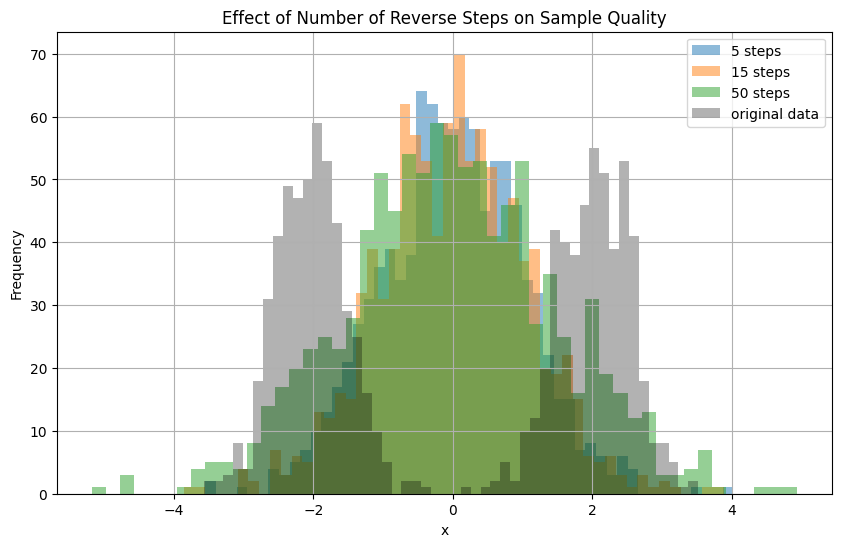

In [12]:
def reverse_diffusion(x_T, steps, noise_scale=0.1):
    """
    Simulated reverse process:
    gradually removes noise, but imperfectly
    """
    x = x_T.copy()
    
    for t in reversed(range(steps)):
        # crude "denoising": shrink toward 0 (acts like learned mean)
        x = x / np.sqrt(alphas[t])
        
        # add small noise (imperfect model)
        x += noise_scale * np.random.randn(*x.shape)
    
    return x


# Start from pure noise
x_T = np.random.randn(n_samples)

step_settings = [5, 15, 50]

plt.figure(figsize=(10, 6))

for steps in step_settings:
    x_gen = reverse_diffusion(x_T, steps)
    plt.hist(x_gen, bins=50, alpha=0.5, label=f"{steps} steps")

# Compare to original data
plt.hist(data, bins=50, alpha=0.3, label="original data", color='black')

plt.title("Effect of Number of Reverse Steps on Sample Quality")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Reverse Process Experiment

## Observation
- **5 steps:** distribution is noisy and poorly structured  
- **15 steps:** some structure emerges but still inaccurate  
- **50 steps:** closer to the original bimodal distribution  

## Insight
More denoising steps improve sample quality.  
This reflects a key property of diffusion models: generation is a **gradual refinement process**, where each step removes a small amount of noise.

Fewer steps -> faster but lower quality  
More steps -> slower but higher quality  


## Limitations and Challenges

1. **Slow sampling**
   - Real diffusion models may require hundreds of steps, making generation computationally expensive.

2. **Approximate reverse process**
   - The reverse process depends on a learned model; errors accumulate across steps.

3. **Trade-off between speed and quality**
   - Reducing steps (for efficiency) often degrades output quality.


## Extension

A natural extension is to use **fewer but smarter steps**, such as:
- improved noise schedules
- deterministic samplers
- or consistency models

A follow-up experiment could compare:
- standard multi-step diffusion
- vs reduced-step sampling

to measure the quality-speed tradeoff more precisely.